In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from math import gcd
from fractions import Fraction

In [22]:
# f(x) = a^x mod N  ->  U|y⟩ = |a·y mod 15⟩
def c_amod15(a, power):
    assert a in [2, 4, 7, 8, 11, 13], "'a' debe ser coprimo con 15"
    U = QuantumCircuit(4)   # 0 to 15
    for _ in range(power):
        if a in [2, 13]:
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        elif a in [7, 8]:
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        elif a in [4, 11]:
            U.swap(1, 3); U.swap(0, 2)
            
    gate = U.to_gate()
    gate.name = f"{a}^{power} mod 15"
    return gate.control(1)

In [23]:
n_count = 8     # number of counting qubits
a = 7           # base for a^r mod 15

In [24]:
def qft_dagger(n):
    qc = QuantumCircuit(n)
    # Invert the order of the qubits
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
     
    # Apply H and inverse controlled phase gates
    for j in range(n):
        for m in range(j):
            # CP with negative angle = inverse of QFT
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)

        qc.h(j)

    qc.name = "QFT dagger"                        
    return qc

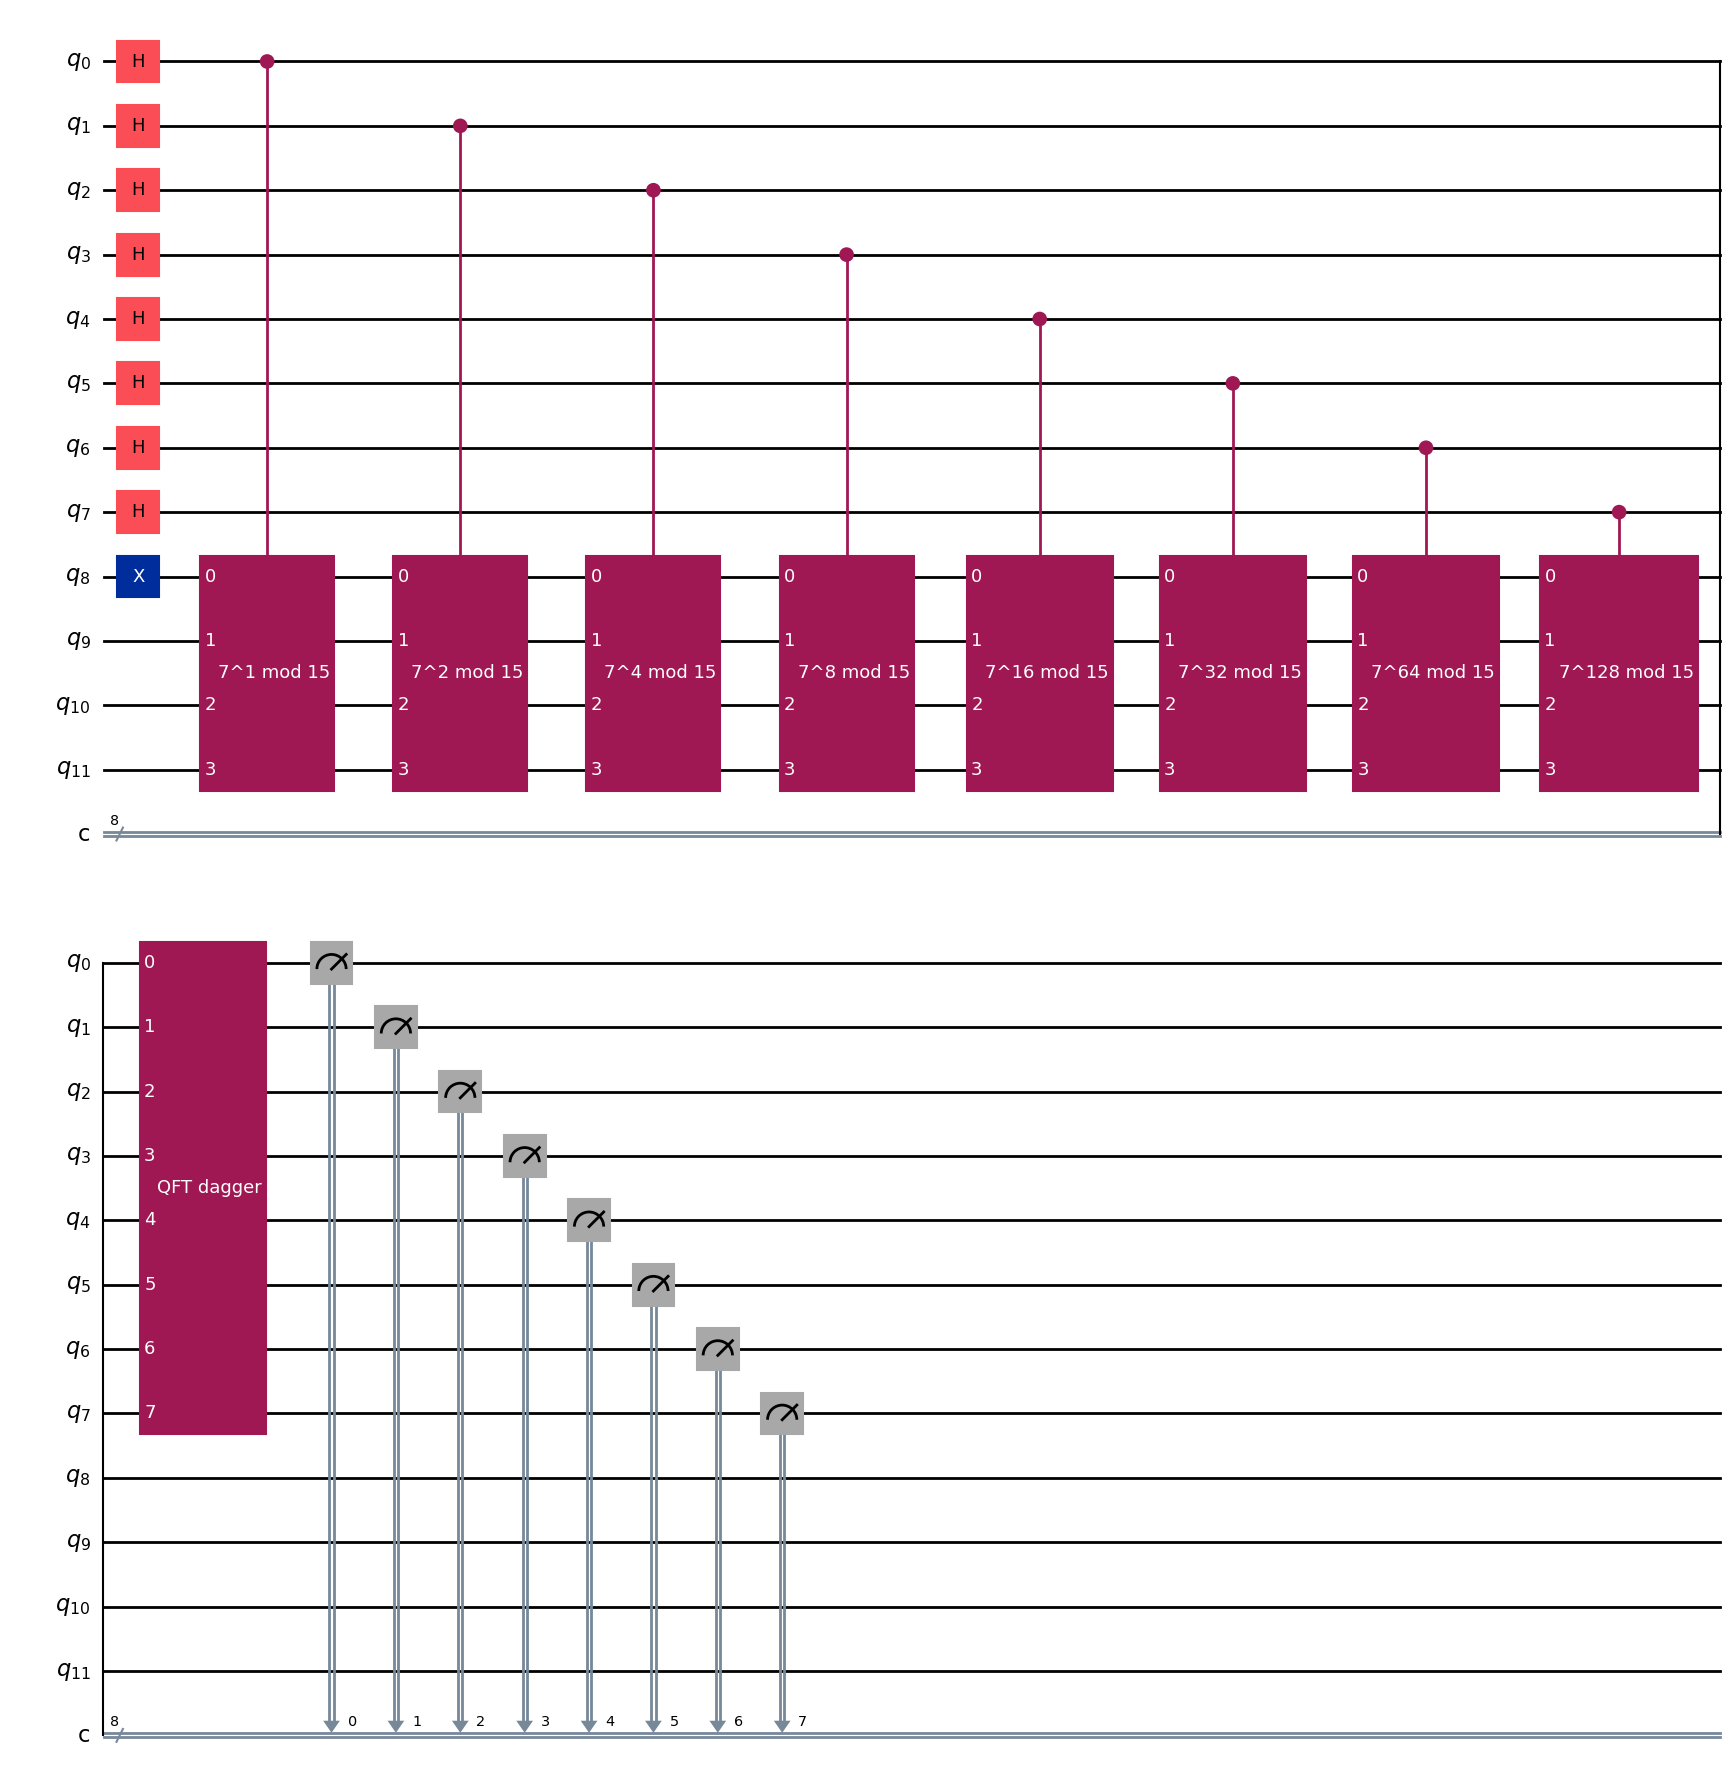

In [25]:
qc = QuantumCircuit(n_count + 4, n_count)

# Initialize counting qubits in superposition
for q in range(n_count):
    qc.h(q)

# Initialize target register to |0001⟩ = 1
qc.x(n_count)

# Apply U^(2^q) controlled by counting qubits
for q in range(n_count):
    qc.append(c_amod15(a, 2**q), [q] + [i + n_count for i in range(4)])

# Apply inverse QFT to counting qubits
qc.append(qft_dagger(n_count), range(n_count))

# Measure counting qubits
qc.measure(range(n_count), range(n_count))

qc.draw('mpl')   

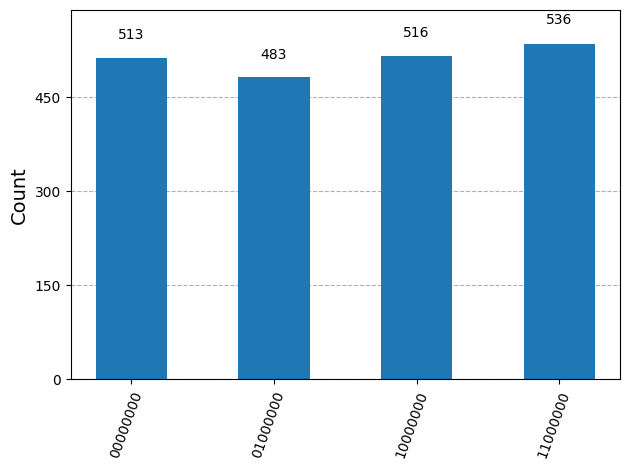

In [26]:
backend = AerSimulator()                          
transpiled = transpile(qc, backend)              
results = backend.run(transpiled, shots=2048).result() 
counts = results.get_counts()
plot_histogram(counts) 